# Split data into train and test parts
from sklearn.model_selection import train_test_split

# Scale numeric values
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [1]:
# Basic libraries for data handling
import pandas as pd
import numpy as np

# Libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn tools for preprocessing and model building
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.callbacks import EarlyStopping

# For saving models
import pickle
import zipfile
import warnings

# Ignore unnecessary warnings
warnings.filterwarnings("ignore")

## Step 1: Upload and load the dataset

First, upload the CSV file in Google Colab.

Expected file name:

`RT_IOT2022.csv`

In [2]:
# Load dataset directly from CSV file
# Make sure RT_IOT2022.csv is uploaded in Colab before running this cell

df = pd.read_csv("RT_IOT2022.csv")

# Show confirmation
print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

# Show first 5 rows
df.head()

Dataset loaded successfully!
Dataset shape: (123117, 85)


,Unnamed: 0,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


## Step 2: Clean the dataset

Here we will:

- remove unwanted columns if they exist
- check missing values
- understand the basic structure of the dataset

In [3]:
# If the dataset has an unwanted index column, remove it safely
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])
    print("Column 'Unnamed: 0' dropped successfully.")
else:
    print("Column 'Unnamed: 0' not found, so nothing was dropped.")

# Show updated shape
print("Updated dataset shape:", df.shape)

# Check missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# Show first rows again
df.head()

Column 'Unnamed: 0' dropped successfully.
Updated dataset shape: (123117, 84)

Missing values in each column:
id.orig_p               0
id.resp_p               0
proto                   0
service                 0
flow_duration           0
                       ..
idle.std                0
fwd_init_window_size    0
bwd_init_window_size    0
fwd_last_window_size    0
Attack_type             0
Length: 84, dtype: int64


,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


## Step 3: Separate features and target

- Features are the input columns
- Target is the output column we want to predict

Our target column is:

`Attack_type`

In [4]:
# Features means input columns
X = df.drop("Attack_type", axis=1)

# Target means output column
y = df["Attack_type"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (123117, 83)
Shape of y: (123117,)


## Step 4: Find categorical columns

Machine learning models cannot directly work with text values.

So we first check which columns contain text data.

In [5]:
# Find columns with object type
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Categorical columns are:")
print(categorical_cols)

Categorical columns are:
Index(['proto', 'service', 'Attack_type'], dtype='object')


## Step 5: Encode categorical columns

We will convert text columns into numbers using Label Encoding.

This is needed because machine learning models work with numeric values.

In [6]:
# Create a dictionary to store encoders
label_encoders = {}

# Encode all categorical columns one by one
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print("Categorical columns encoded successfully.")

# Show first rows after encoding
df.head()

Categorical columns encoded successfully.


,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,38667,1883,1,5,32.011598,9,5,3,3,0.281148,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,3
1,51143,1883,1,5,31.883584,9,5,3,3,0.282277,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,3
2,44761,1883,1,5,32.124053,9,5,3,3,0.280164,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,3
3,60893,1883,1,5,31.961063,9,5,3,3,0.281593,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,3
4,51087,1883,1,5,31.902362,9,5,3,3,0.282111,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,3


In [7]:
# Recreate features and target after encoding
X = df.drop("Attack_type", axis=1)
y = df["Attack_type"]

print("Shape of X after encoding:", X.shape)
print("Shape of y after encoding:", y.shape)

Shape of X after encoding: (123117, 83)
Shape of y after encoding: (123117,)


## Step 6: Split the dataset

We divide the dataset into:

- training data → used to train the model
- testing data → used to test the model

In [8]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (98493, 83)
X_test shape: (24624, 83)
y_train shape: (98493,)
y_test shape: (24624,)


## Step 7: Scale the data

Feature scaling helps models like:

- Logistic Regression
- KNN
- SVM
- ANN
- LSTM

It makes the values come to a similar range.

In [9]:
# Create scaler object
scaler = StandardScaler()

# Fit scaler on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Only transform test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


## Step 8: Create helper functions

To avoid repeating the same code many times, we will create:

- one function to evaluate a model
- one function to plot confusion matrix

In [10]:
# Function to train model and calculate metrics
def evaluate_model(model, X_train_data, X_test_data, y_train_data, y_test_data, model_name):
    # Train the model
    model.fit(X_train_data, y_train_data)

    # Make predictions
    y_pred = model.predict(X_test_data)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test_data, y_pred)
    precision = precision_score(y_test_data, y_pred, average="weighted")
    recall = recall_score(y_test_data, y_pred, average="weighted")
    f1 = f1_score(y_test_data, y_pred, average="weighted")

    # Print results
    print("\n" + "="*50)
    print(model_name, "Results")
    print("="*50)
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nClassification Report:")
    print(classification_report(y_test_data, y_pred))

    # Return all important outputs
    return model, y_pred, accuracy, precision, recall, f1


# Function to plot confusion matrix
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

## Step 9: Train Logistic Regression


Logistic Regression Results
Accuracy : 0.9910250162443145
Precision: 0.9910306598577173
Recall   : 0.9910250162443145
F1 Score : 0.9908947549811011

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.94      1550
           1       0.94      0.79      0.86       107
           2       1.00      1.00      1.00     18932
           3       1.00      1.00      1.00       829
           4       0.86      0.86      0.86         7
           5       0.71      0.83      0.77         6
           6       1.00      1.00      1.00       400
           7       0.99      1.00      0.99       200
           8       0.96      0.98      0.97       518
           9       1.00      1.00      1.00       402
          10       0.93      0.97      0.95      1622
          11       0.88      0.57      0.69        51

    accuracy                           0.99     24624
   macro avg       0.94      0.91      0.92     24624
weighted avg   

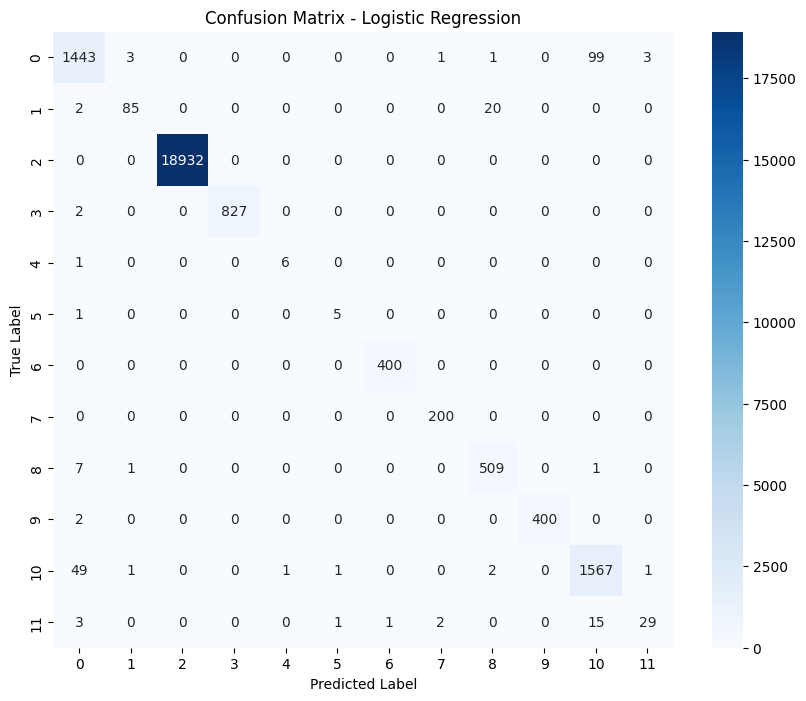

In [11]:
# Create Logistic Regression model
log_model = LogisticRegression(max_iter=1000)

# Train and evaluate
log_model, y_pred_log, log_acc, log_pre, log_rec, log_f1 = evaluate_model(
    log_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    "Logistic Regression"
)

# Plot confusion matrix
plot_confusion(y_test, y_pred_log, "Confusion Matrix - Logistic Regression")

## Step 10: Train K-Nearest Neighbors


KNN Results
Accuracy : 0.9963450292397661
Precision: 0.9963470358072155
Recall   : 0.9963450292397661
F1 Score : 0.9963380538767854

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1550
           1       0.97      0.95      0.96       107
           2       1.00      1.00      1.00     18932
           3       1.00      1.00      1.00       829
           4       0.86      0.86      0.86         7
           5       0.83      0.83      0.83         6
           6       0.99      1.00      1.00       400
           7       1.00      1.00      1.00       200
           8       0.99      0.99      0.99       518
           9       1.00      1.00      1.00       402
          10       0.99      0.98      0.98      1622
          11       0.91      0.84      0.88        51

    accuracy                           1.00     24624
   macro avg       0.96      0.95      0.96     24624
weighted avg       1.00      1.

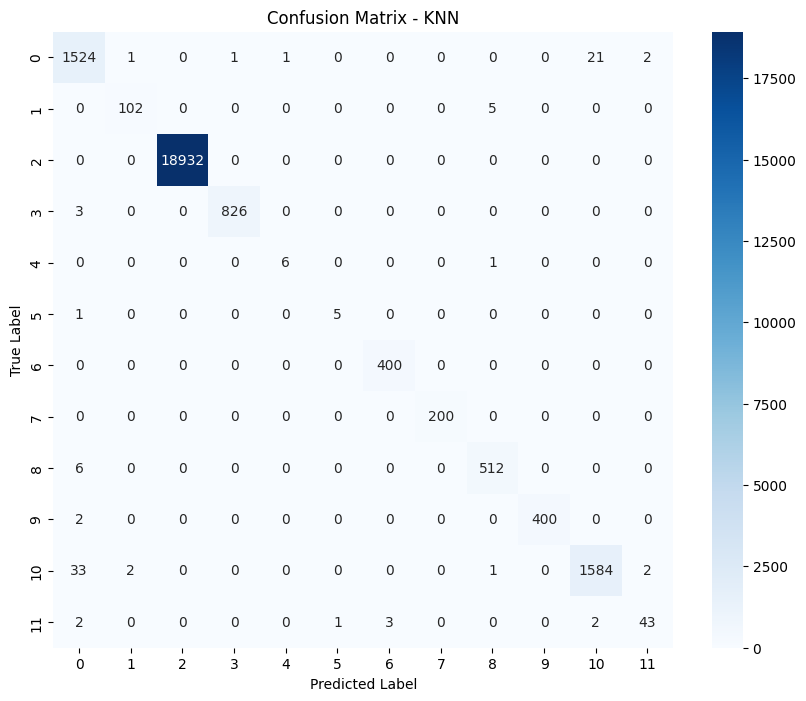

In [12]:
# Create KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train and evaluate
knn_model, y_pred_knn, knn_acc, knn_pre, knn_rec, knn_f1 = evaluate_model(
    knn_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    "KNN"
)

# Plot confusion matrix
plot_confusion(y_test, y_pred_knn, "Confusion Matrix - KNN")

## Step 11: Train Random Forest


Random Forest Results
Accuracy : 0.9984161793372319
Precision: 0.9984359685740297
Recall   : 0.9984161793372319
F1 Score : 0.9984184825521044

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1550
           1       1.00      0.99      1.00       107
           2       1.00      1.00      1.00     18932
           3       1.00      1.00      1.00       829
           4       0.78      1.00      0.88         7
           5       1.00      0.83      0.91         6
           6       1.00      1.00      1.00       400
           7       1.00      1.00      1.00       200
           8       0.99      0.99      0.99       518
           9       1.00      1.00      1.00       402
          10       0.99      0.99      0.99      1622
          11       0.98      0.94      0.96        51

    accuracy                           1.00     24624
   macro avg       0.98      0.98      0.98     24624
weighted avg       1.

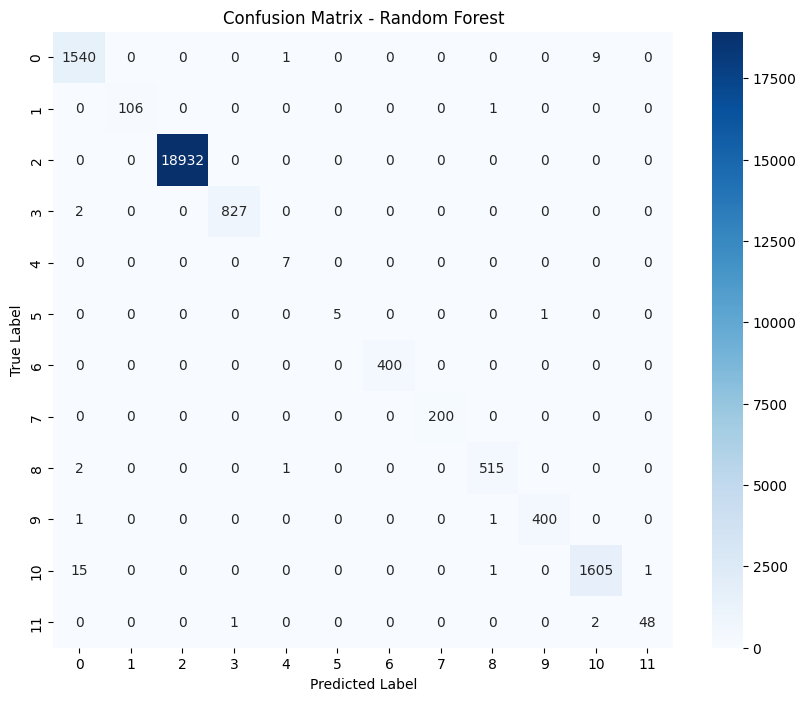

In [13]:
# Create Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train and evaluate
rf_model, y_pred_rf, rf_acc, rf_pre, rf_rec, rf_f1 = evaluate_model(
    rf_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    "Random Forest"
)

# Plot confusion matrix
plot_confusion(y_test, y_pred_rf, "Confusion Matrix - Random Forest")

## Step 12: Train Support Vector Machine


SVM Results
Accuracy : 0.9939896036387265
Precision: 0.9941269195115033
Recall   : 0.9939896036387265
F1 Score : 0.9938666945654047

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1550
           1       1.00      0.80      0.89       107
           2       1.00      1.00      1.00     18932
           3       1.00      0.99      1.00       829
           4       1.00      0.86      0.92         7
           5       0.83      0.83      0.83         6
           6       0.99      1.00      1.00       400
           7       1.00      1.00      1.00       200
           8       0.96      0.98      0.97       518
           9       1.00      1.00      1.00       402
          10       0.98      0.96      0.97      1622
          11       1.00      0.59      0.74        51

    accuracy                           0.99     24624
   macro avg       0.98      0.92      0.94     24624
weighted avg       0.99      0.

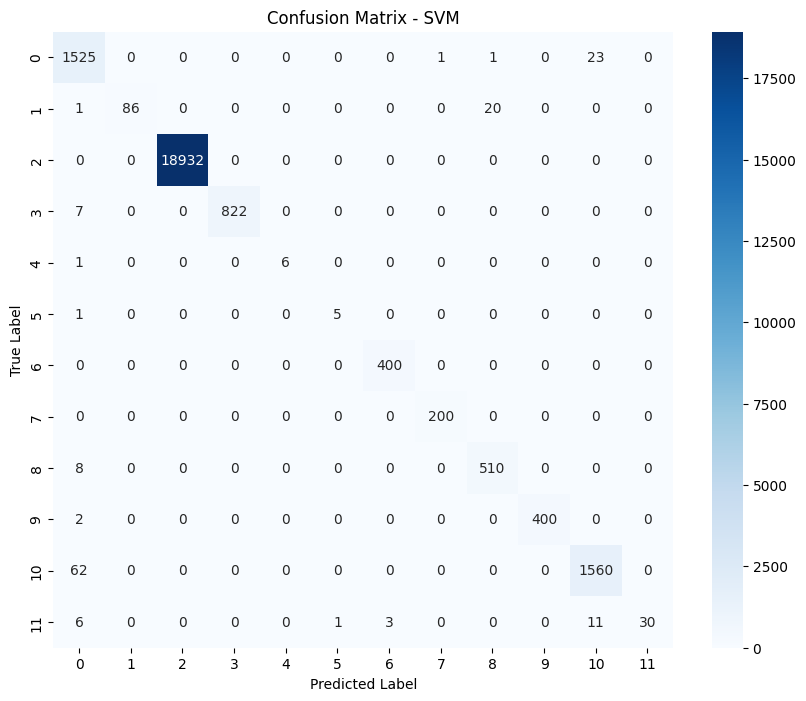

In [14]:
# Create SVM model
svm_model = SVC(kernel="rbf")

# Train and evaluate
svm_model, y_pred_svm, svm_acc, svm_pre, svm_rec, svm_f1 = evaluate_model(
    svm_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    "SVM"
)

# Plot confusion matrix
plot_confusion(y_test, y_pred_svm, "Confusion Matrix - SVM")

## Step 13: Train Artificial Neural Network (ANN)

ANN is a deep learning model.

It takes the scaled data and learns patterns for classification.

In [15]:
# Number of unique classes in target
num_classes = len(np.unique(y))

# Build ANN model
ann_model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(64, activation="relu"),
    Dense(num_classes, activation="softmax")
])

# Compile ANN model
ann_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Early stopping helps stop training if validation loss does not improve
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train ANN model
history_ann = ann_model.fit(
    X_train_scaled,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9813 - loss: 0.0724 - val_accuracy: 0.9910 - val_loss: 0.0508
Epoch 2/10
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9921 - loss: 0.0273 - val_accuracy: 0.9937 - val_loss: 0.0437
Epoch 3/10
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9939 - loss: 0.0201 - val_accuracy: 0.9929 - val_loss: 0.0423
Epoch 4/10
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9945 - loss: 0.0211 - val_accuracy: 0.9923 - val_loss: 0.0495
Epoch 5/10
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9949 - loss: 0.0162 - val_accuracy: 0.9936 - val_loss: 0.0603
Epoch 6/10
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9953 - loss: 0.0141 - val_accuracy: 0.9949 - val_loss: 0.0430


770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

ANN Results
Accuracy : 0.9934616634178037
Precision: 0.9936403456982842
Recall   : 0.9934616634178037
F1 Score : 0.993431000614383

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.94      0.96      1550
           1       0.99      0.80      0.89       107
           2       1.00      1.00      1.00     18932
           3       1.00      1.00      1.00       829
           4       1.00      0.86      0.92         7
           5       0.80      0.67      0.73         6
           6       0.99      1.00      1.00       400
           7       1.00      1.00      1.00       200
           8       0.96      0.98      0.97       518
           9       1.00      1.00      1.00       402
          10       0.94      0.99      0.96      1622
          11       0.72      0.75      0.73        51

    accuracy                           0.99     24624
   macro avg       0.95      0.91      0.93  

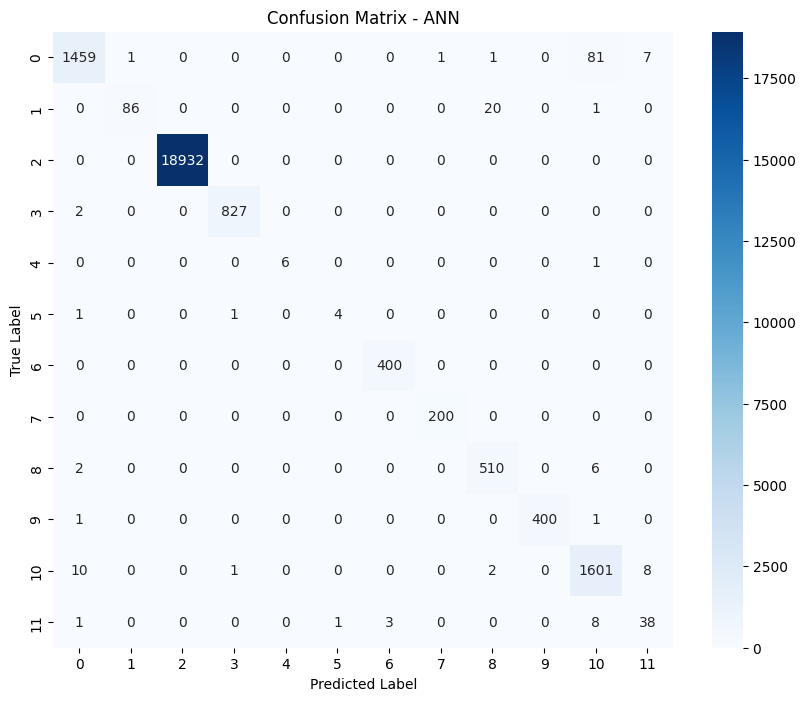

In [16]:
# Predict probabilities
y_pred_ann_prob = ann_model.predict(X_test_scaled)

# Convert probabilities into class labels
y_pred_ann = np.argmax(y_pred_ann_prob, axis=1)

# Calculate metrics
ann_acc = accuracy_score(y_test, y_pred_ann)
ann_pre = precision_score(y_test, y_pred_ann, average="weighted")
ann_rec = recall_score(y_test, y_pred_ann, average="weighted")
ann_f1 = f1_score(y_test, y_pred_ann, average="weighted")

# Print results
print("\n" + "="*50)
print("ANN Results")
print("="*50)
print("Accuracy :", ann_acc)
print("Precision:", ann_pre)
print("Recall   :", ann_rec)
print("F1 Score :", ann_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ann))

# Plot confusion matrix
plot_confusion(y_test, y_pred_ann, "Confusion Matrix - ANN")

## Step 14: Train LSTM model

LSTM is usually used for sequential data.

Here we reshape the tabular dataset so that it can be given to the LSTM model.

In [17]:
# Reshape scaled data into 3D format for LSTM
# Shape becomes: [samples, timesteps, features]
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

print("LSTM training shape:", X_train_lstm.shape)
print("LSTM testing shape:", X_test_lstm.shape)

LSTM training shape: (98493, 83, 1)
LSTM testing shape: (24624, 83, 1)


In [18]:
# Build LSTM model
lstm_model = Sequential([
    LSTM(64, input_shape=(X_train_lstm.shape[1], 1)),
    Dense(32, activation="relu"),
    Dense(num_classes, activation="softmax")
])

# Compile LSTM model
lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train LSTM model
history_lstm = lstm_model.fit(
    X_train_lstm,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 103s 41ms/step - accuracy: 0.9035 - loss: 0.3419 - val_accuracy: 0.8503 - val_loss: 0.7916
Epoch 2/10
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 144s 42ms/step - accuracy: 0.9507 - loss: 0.1602 - val_accuracy: 0.9732 - val_loss: 0.0776
Epoch 3/10
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 138s 40ms/step - accuracy: 0.9764 - loss: 0.0748 - val_accuracy: 0.9688 - val_loss: 0.1003


770/770 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step

LSTM Results
Accuracy : 0.851811241065627
Precision: 0.8063507165287126
Recall   : 0.851811241065627
F1 Score : 0.8077501449624455

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.19      0.30      1550
           1       0.34      0.13      0.19       107
           2       0.85      1.00      0.92     18932
           3       0.99      0.93      0.96       829
           4       0.00      0.00      0.00         7
           5       0.00      0.00      0.00         6
           6       0.00      0.00      0.00       400
           7       0.88      1.00      0.94       200
           8       0.53      0.05      0.09       518
           9       0.00      0.00      0.00       402
          10       0.83      0.46      0.59      1622
          11       0.00      0.00      0.00        51

    accuracy                           0.85     24624
   macro avg       0.43      0.31      0.33

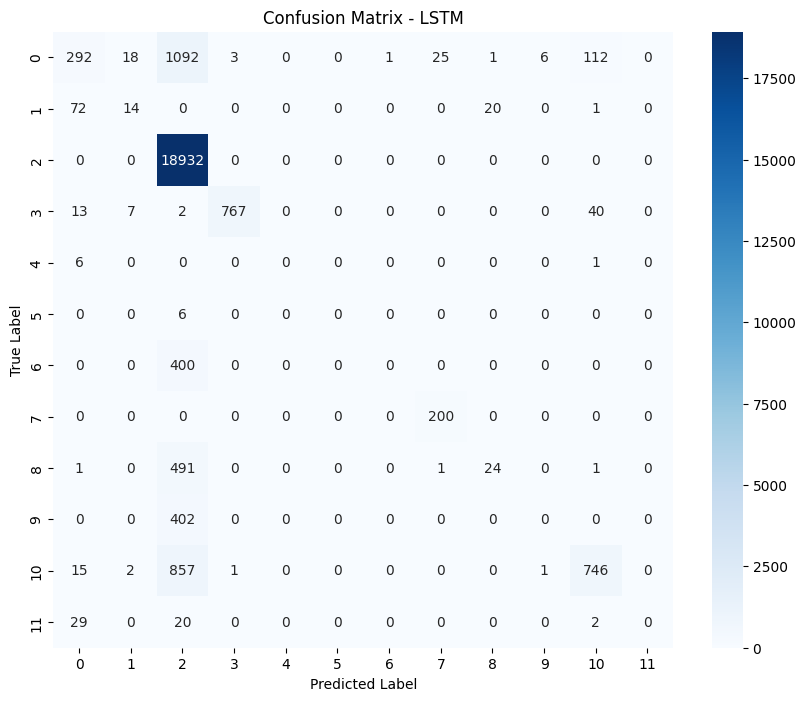

In [19]:
# Predict probabilities
y_pred_lstm_prob = lstm_model.predict(X_test_lstm)

# Convert probabilities into class labels
y_pred_lstm = np.argmax(y_pred_lstm_prob, axis=1)

# Calculate metrics
lstm_acc = accuracy_score(y_test, y_pred_lstm)
lstm_pre = precision_score(y_test, y_pred_lstm, average="weighted")
lstm_rec = recall_score(y_test, y_pred_lstm, average="weighted")
lstm_f1 = f1_score(y_test, y_pred_lstm, average="weighted")

# Print results
print("\n" + "="*50)
print("LSTM Results")
print("="*50)
print("Accuracy :", lstm_acc)
print("Precision:", lstm_pre)
print("Recall   :", lstm_rec)
print("F1 Score :", lstm_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lstm))

# Plot confusion matrix
plot_confusion(y_test, y_pred_lstm, "Confusion Matrix - LSTM")

## Step 15: Compare all model results

Now we will collect all model scores in one table.

This makes comparison easy.

In [20]:
# Create a table of results
results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Random Forest", "SVM", "ANN", "LSTM"],
    "Accuracy": [log_acc, knn_acc, rf_acc, svm_acc, ann_acc, lstm_acc],
    "Precision": [log_pre, knn_pre, rf_pre, svm_pre, ann_pre, lstm_pre],
    "Recall": [log_rec, knn_rec, rf_rec, svm_rec, ann_rec, lstm_rec],
    "F1 Score": [log_f1, knn_f1, rf_f1, svm_f1, ann_f1, lstm_f1]
})

# Show table
results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.998416,0.998436,0.998416,0.998418
1,KNN,0.996345,0.996347,0.996345,0.996338
3,SVM,0.993990,0.994127,0.993990,0.993867
4,ANN,0.993462,0.993640,0.993462,0.993431
0,Logistic Regression,0.991025,0.991031,0.991025,0.990895
5,LSTM,0.851811,0.806351,0.851811,0.807750


## Step 16: Plot model comparison charts

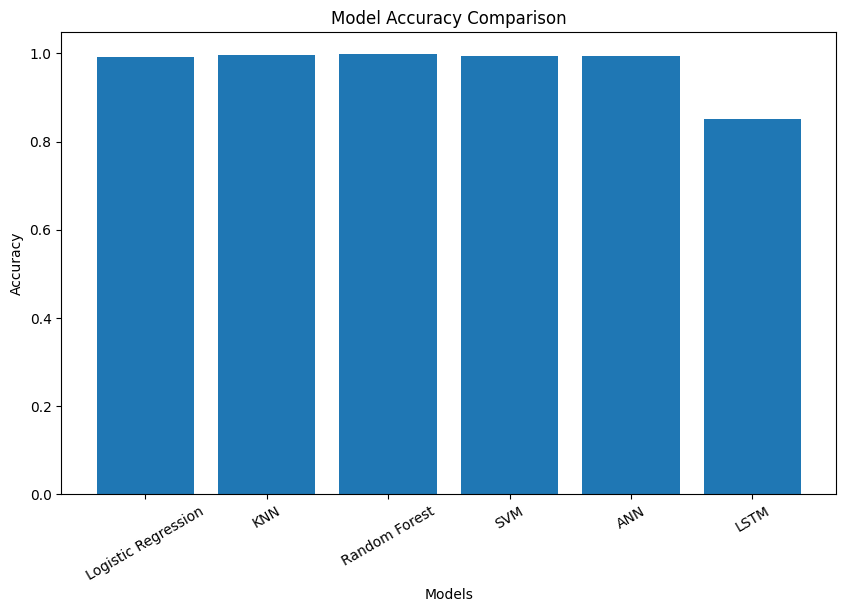

In [21]:
# Plot accuracy comparison
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

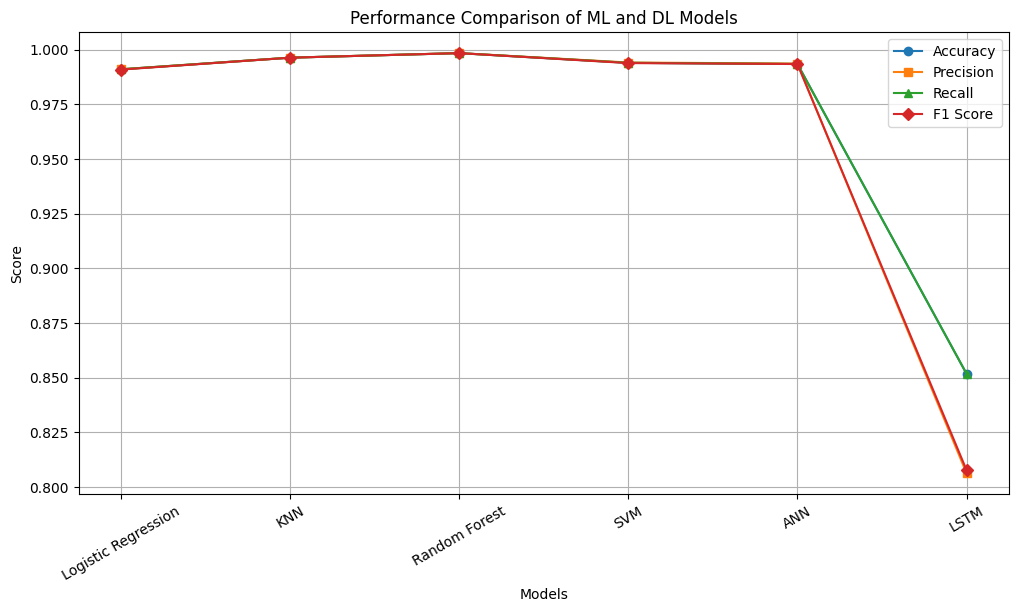

In [22]:
# Plot all metric comparisons
plt.figure(figsize=(12, 6))

plt.plot(results_df["Model"], results_df["Accuracy"], marker="o", label="Accuracy")
plt.plot(results_df["Model"], results_df["Precision"], marker="s", label="Precision")
plt.plot(results_df["Model"], results_df["Recall"], marker="^", label="Recall")
plt.plot(results_df["Model"], results_df["F1 Score"], marker="D", label="F1 Score")

plt.title("Performance Comparison of ML and DL Models")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.legend()
plt.grid(True)
plt.show()

## Step 17: Basic EDA plots

We will create:

- class distribution plot
- correlation heatmap
- pairplot for some important columns

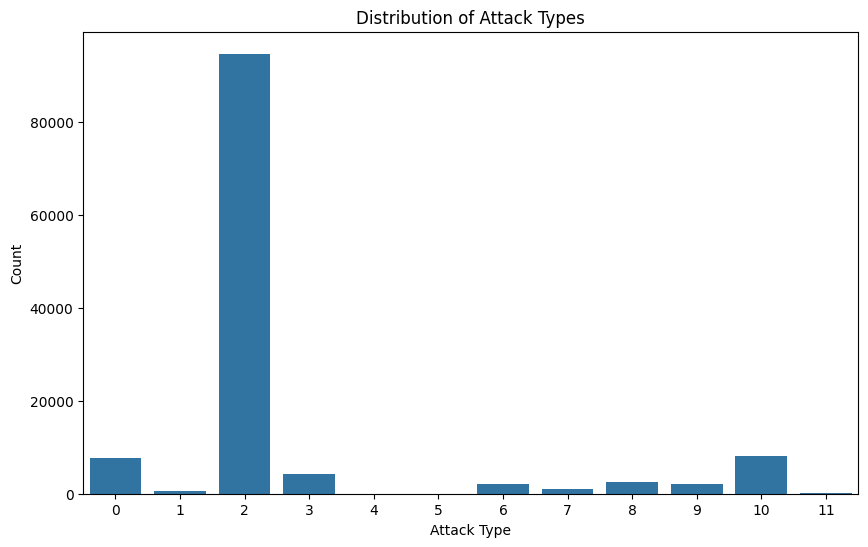

In [23]:
# Plot target class distribution
plt.figure(figsize=(10, 6))
sns.countplot(x="Attack_type", data=df)
plt.title("Distribution of Attack Types")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.show()

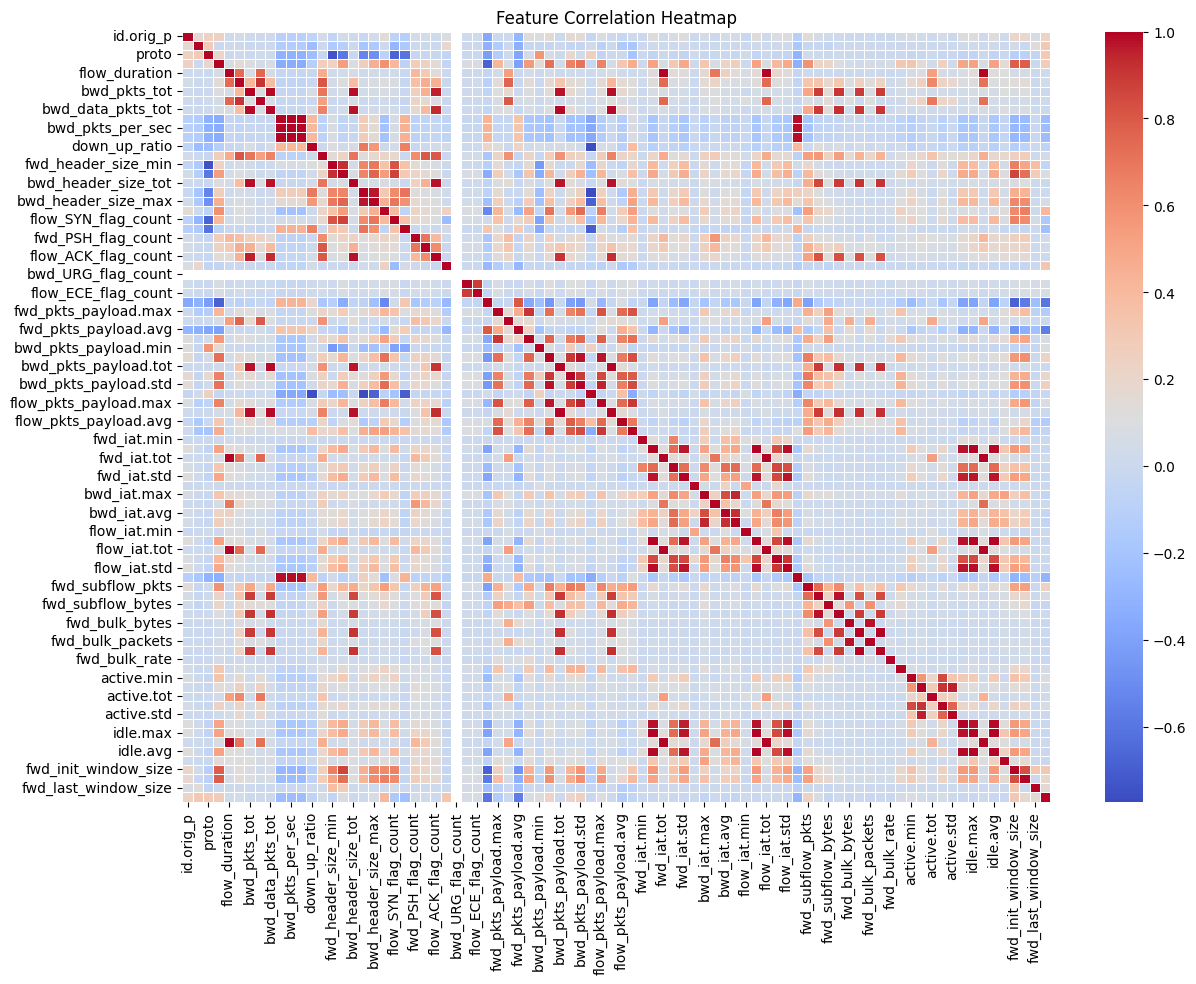

In [24]:
# Plot feature correlation heatmap
plt.figure(figsize=(14, 10))
correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

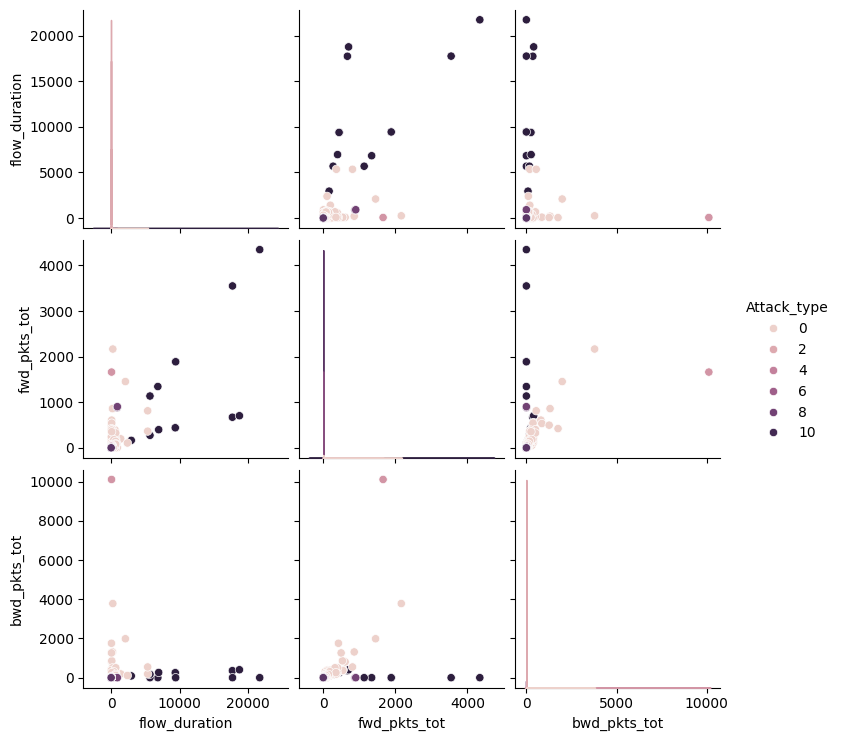

In [25]:
# Plot pairplot only if these columns are present
pairplot_cols = ["flow_duration", "fwd_pkts_tot", "bwd_pkts_tot", "Attack_type"]

available_cols = [col for col in pairplot_cols if col in df.columns]

if len(available_cols) == 4:
    sns.pairplot(df[available_cols], hue="Attack_type")
    plt.show()
else:
    print("Some pairplot columns are not available in the dataset, so pairplot was skipped.")

## Step 18: Save trained models

We will save:

- machine learning models as `.pkl`
- deep learning models as `.h5`
- scaler
- label encoders

In [26]:
# Save machine learning models
with open("log_model.pkl", "wb") as f:
    pickle.dump(log_model, f)

with open("knn_model.pkl", "wb") as f:
    pickle.dump(knn_model, f)

with open("rf_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

with open("svm_model.pkl", "wb") as f:
    pickle.dump(svm_model, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save label encoders
with open("label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

# Save deep learning models
ann_model.save("ann_model.h5")
lstm_model.save("lstm_model.h5")

print("All models saved successfully.")

All models saved successfully.


## Step 19: Zip all saved files

This makes downloading easier.

In [27]:
# List of files to zip
files_to_zip = [
    "log_model.pkl",
    "knn_model.pkl",
    "rf_model.pkl",
    "svm_model.pkl",
    "scaler.pkl",
    "label_encoders.pkl",
    "ann_model.h5",
    "lstm_model.h5"
]

zip_filename = "all_models.zip"

# Create zip file
with zipfile.ZipFile(zip_filename, "w") as z:
    for file in files_to_zip:
        z.write(file)

print("ZIP file created successfully:", zip_filename)

ZIP file created successfully: all_models.zip


In [28]:
# Download zip file in Colab
from google.colab import files
files.download("all_models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

In this notebook, we successfully:

- loaded and cleaned the RT_IOT2022 dataset
- encoded categorical columns
- split and scaled the dataset
- trained machine learning models:
  - Logistic Regression
  - KNN
  - Random Forest
  - SVM
- trained deep learning models:
  - ANN
  - LSTM
- evaluated all models using:
  - Accuracy
  - Precision
  - Recall
  - F1-score
- plotted confusion matrices and performance comparison graphs
- saved all trained models for future use

This notebook provides a complete pipeline for attack type classification using both machine learning and deep learning approaches.